# `tsp2000`（4 个方法）日志解析与逐实例胜负统计\n
\n
本 notebook 用于分析：`results/benchmarks/tsp_datasets/` 下 **4 个方法（omni/lehd/elg/icam）** 在数据集 `test_dataset_tsp_uniform/test_tsp2000_nums128_uniform.pt` 上的结果。\n
\n
重点输出：\n
- **每个方法领先（win）的实例数量**\n
- **每个方法领先的实例列表**（用日志中的 `Completed k/128` 的 `k` 作为实例编号）\n
- 同时给出 `Score` 与 `Augmented Score` 两种口径（默认以 `Augmented Score` 做胜负统计）\n
\n
说明：这类 dataset 没有 TSPLIB 的实例名，日志里也不打印 name，因此这里把 `Completed  37/128` 的 `37` 当作 `instance_id=37`。\n

In [4]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('.').resolve()
LOG_ROOT = ROOT / 'results' / 'benchmarks' / 'tsp_datasets' / 'logs'
DATASET_KEY = 'test_dataset_tsp_uniform__test_tsp2000_nums128_uniform.pt.log'

METHODS = ['omni', 'lehd', 'elg', 'icam']

print('ROOT:', ROOT)
print('LOG_ROOT exists:', LOG_ROOT.exists(), LOG_ROOT)
print('methods:', METHODS)


ROOT: /mnt/d/Study/3/neural-solver-selection/benchmarks
LOG_ROOT exists: True /mnt/d/Study/3/neural-solver-selection/benchmarks/results/benchmarks/tsp_datasets/logs
methods: ['omni', 'lehd', 'elg', 'icam']


## 1) 解析器：从日志提取每个实例的 `Score / Augmented Score`\n
\n
目标：从类似下面的行提取结构化记录：\n
```\n
Eval ==> Problem[tsp], Size[2000], Completed  31/128(24.22%), Score: 42.8819, Augmented Score: 42.5842\n
```\n

In [5]:
EVAL_LINE_RE = re.compile(
    r"Eval ==> Problem\[tsp\], Size\[(?P<size>\d+)\], Completed\s+"
    r"(?P<done>\d+)/(?P<total>\d+)\([^\)]*\), Score: (?P<score>[0-9.]+), Augmented Score: (?P<aug>[0-9.]+)"
)


@dataclass(frozen=True)
class InstanceResult:
    instance_id: int  # 1..total (from Completed k/total)
    total: int
    score: float
    aug_score: float


def parse_easynco_eval_log(path: Path) -> Dict[int, InstanceResult]:
    text = path.read_text(encoding='utf-8', errors='ignore')
    out: Dict[int, InstanceResult] = {}
    for m in EVAL_LINE_RE.finditer(text):
        done = int(m['done'])
        total = int(m['total'])
        score = float(m['score'])
        aug = float(m['aug'])
        out[done] = InstanceResult(instance_id=done, total=total, score=score, aug_score=aug)
    return out


def format_table(rows: List[List[object]], headers: List[str]) -> str:
    cols = len(headers)
    assert all(len(r) == cols for r in rows)
    col_widths = [len(str(h)) for h in headers]
    for r in rows:
        for j, v in enumerate(r):
            col_widths[j] = max(col_widths[j], len(str(v)))
    
    def fmt_row(r: List[object]) -> str:
        return ' | '.join(str(v).ljust(col_widths[j]) for j, v in enumerate(r))
    
    sep = '-+-'.join('-' * w for w in col_widths)
    out_lines = [fmt_row(headers), sep]
    out_lines.extend(fmt_row(r) for r in rows)
    return '\n'.join(out_lines)


## 2) 读取 4 个方法的日志，并做覆盖检查\n
\n
我们会统计：\n
- 每个方法解析到多少个实例（期望 128）\n
- 共同子集（4 个方法都跑到的实例）有多少\n

In [6]:
log_paths = {}
for m in METHODS:
    p = LOG_ROOT / m / DATASET_KEY
    log_paths[m] = p

missing = [m for m, p in log_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing log files for: {missing}. Expected under: {LOG_ROOT}')

results_by_method: Dict[str, Dict[int, InstanceResult]] = {}
for m, p in log_paths.items():
    r = parse_easynco_eval_log(p)
    results_by_method[m] = r
    totals = sorted({v.total for v in r.values()})
    print(f'[{m}] parsed_instances={len(r)} total_values={totals[:5]}')

common_ids = None
for m in METHODS:
    ids = set(results_by_method[m].keys())
    common_ids = ids if common_ids is None else (common_ids & ids)
common_ids = sorted(common_ids or [])

print('common_instances:', len(common_ids), 'min_id:', (min(common_ids) if common_ids else None), 'max_id:', (max(common_ids) if common_ids else None))

rows = []
for m in METHODS:
    ids = sorted(results_by_method[m].keys())
    miss = sorted(set(common_ids) ^ (set(common_ids) & set(ids)))
    rows.append([m, len(ids), ids[0] if ids else None, ids[-1] if ids else None])
print('\n' + format_table(rows, headers=['method', 'parsed_n', 'min_id', 'max_id']))


[omni] parsed_instances=128 total_values=[128]
[lehd] parsed_instances=128 total_values=[128]
[elg] parsed_instances=128 total_values=[128]
[icam] parsed_instances=128 total_values=[128]
common_instances: 128 min_id: 1 max_id: 128

method | parsed_n | min_id | max_id
-------+----------+--------+-------
omni   | 128      | 1      | 128   
lehd   | 128      | 1      | 128   
elg    | 128      | 1      | 128   
icam   | 128      | 1      | 128   


## 3) 胜负统计（重点）：谁在逐实例上赢得最多？\n
\n
默认口径：**Augmented Score 越小越好**。\n
\n
同时也会输出 `Score`（无 augmentation 口径）作为参考。\n
\n
Tie 处理：如果多个方法在同一个实例上达到同样的最小值（在容忍阈值内），记为 tie，并把该实例列到 `tie_winners` 中。\n

In [7]:
def compute_wins(
    values_by_method: Dict[str, Dict[int, float]],
    instance_ids: List[int],
    *,
    tol: float = 1e-9,
) -> Tuple[Dict[str, List[int]], Dict[str, List[int]], List[int], Dict[int, List[str]]]:
    """Return (strict_wins, wins_including_ties, tie_instance_ids, tie_winners_by_instance)."""
    strict: Dict[str, List[int]] = {m: [] for m in values_by_method}
    incl: Dict[str, List[int]] = {m: [] for m in values_by_method}
    ties: List[int] = []
    tie_winners: Dict[int, List[str]] = {}

    methods = list(values_by_method.keys())
    for iid in instance_ids:
        vals = [(m, values_by_method[m][iid]) for m in methods]
        best = min(v for _, v in vals)
        winners = [m for m, v in vals if abs(v - best) <= tol]

        if len(winners) == 1:
            strict[winners[0]].append(iid)
        else:
            ties.append(iid)
            tie_winners[iid] = winners

        for w in winners:
            incl[w].append(iid)

    return strict, incl, ties, tie_winners


# Build per-instance numeric views
score_by_method: Dict[str, Dict[int, float]] = {
    m: {iid: results_by_method[m][iid].score for iid in common_ids}
    for m in METHODS
}
aug_by_method: Dict[str, Dict[int, float]] = {
    m: {iid: results_by_method[m][iid].aug_score for iid in common_ids}
    for m in METHODS
}

strict_aug, incl_aug, ties_aug, tie_winners_aug = compute_wins(aug_by_method, common_ids)
strict_score, incl_score, ties_score, tie_winners_score = compute_wins(score_by_method, common_ids)

rows = []
for m in METHODS:
    rows.append([
        m,
        len(strict_aug[m]),
        len(incl_aug[m]),
        len(strict_score[m]),
        len(incl_score[m]),
    ])

rows.append(['TIES', len(ties_aug), '-', len(ties_score), '-'])

print(format_table(
    rows,
    headers=[
        'method',
        'wins_strict(aug)',
        'wins_with_ties(aug)',
        'wins_strict(score)',
        'wins_with_ties(score)',
    ],
))

print('\n[Augmented] example winners lists (first 20 ids):')
for m in METHODS:
    print(f'  {m}: {strict_aug[m][:20]} ... total={len(strict_aug[m])}')

if ties_aug:
    print('\n[Augmented] ties (first 20):', ties_aug[:20], '... total=', len(ties_aug))
    for iid in ties_aug[:10]:
        print('  tie instance', iid, 'winners=', tie_winners_aug[iid])


method | wins_strict(aug) | wins_with_ties(aug) | wins_strict(score) | wins_with_ties(score)
-------+------------------+---------------------+--------------------+----------------------
omni   | 0                | 0                   | 0                  | 0                    
lehd   | 4                | 4                   | 32                 | 32                   
elg    | 0                | 0                   | 0                  | 0                    
icam   | 124              | 124                 | 96                 | 96                   
TIES   | 0                | -                   | 0                  | -                    

[Augmented] example winners lists (first 20 ids):
  omni: [] ... total=0
  lehd: [4, 18, 31, 84] ... total=4
  elg: [] ... total=0
  icam: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22] ... total=124


## 4) 输出：每个方法“领先实例列表”（完整列表）\n
\n
为了便于你直接复制到报告/文档，这里把每个方法在 `Augmented Score` 口径下的 **严格 win 列表** 和 **win(含 tie) 列表** 都打印出来。\n

In [8]:
print('=== Strict wins by Augmented Score (full lists) ===')
for m in METHODS:
    print(f'[{m}] n={len(strict_aug[m])}\n{strict_aug[m]}\n')

print('=== Wins (including ties) by Augmented Score (full lists) ===')
for m in METHODS:
    print(f'[{m}] n={len(incl_aug[m])}\n{incl_aug[m]}\n')

if ties_aug:
    print('=== Tie details (Augmented Score) ===')
    for iid in ties_aug:
        print(f'instance_id={iid} tie_winners={tie_winners_aug[iid]}')


=== Strict wins by Augmented Score (full lists) ===
[omni] n=0
[]

[lehd] n=4
[4, 18, 31, 84]

[elg] n=0
[]

[icam] n=124
[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]

=== Wins (including ties) by Augmented Score (full lists) ===
[omni] n=0
[]

[lehd] n=4
[4, 18, 31, 84]

[elg] n=0
[]

[icam] n=124
[1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62

## 5) 额外分析（可选）：每个实例的“最佳 vs 次佳”差距\n
\n
这能帮助判断：\n
- 胜负是不是“非常接近”（差距极小，容易被随机性/数值误差影响）\n
- 哪些实例是“分歧很大”的（某些方法明显更适合）\n

In [9]:
def best_second_gap(values: List[float]) -> float:
    vals = sorted(values)
    if len(vals) < 2:
        return float('nan')
    return vals[1] - vals[0]


gaps = []
for iid in common_ids:
    vals = [aug_by_method[m][iid] for m in METHODS]
    gaps.append(best_second_gap(vals))
gaps = np.array(gaps, dtype=float)

print('gap(second-best - best) stats (Augmented Score):')
print('  min:', float(np.min(gaps)))
print('  p10:', float(np.quantile(gaps, 0.10)))
print('  median:', float(np.median(gaps)))
print('  p90:', float(np.quantile(gaps, 0.90)))
print('  max:', float(np.max(gaps)))

# show top-10 most "separating" instances
idx_sorted = np.argsort(-gaps)  # descending
topk = 10
print(f'\nTop-{topk} instances with largest gap:')
for k in range(topk):
    pos = int(idx_sorted[k])
    iid = common_ids[pos]
    vals = sorted([(m, aug_by_method[m][iid]) for m in METHODS], key=lambda x: x[1])
    best_m, best_v = vals[0]
    second_m, second_v = vals[1]
    print(f'  instance {iid}: best={best_m} {best_v:.6f}, second={second_m} {second_v:.6f}, gap={gaps[pos]:.6f}')


gap(second-best - best) stats (Augmented Score):
  min: 0.009900000000001796
  p10: 0.1320799999999977
  median: 0.43819999999999837
  p90: 1.2645499999999978
  max: 2.9277000000000015

Top-10 instances with largest gap:
  instance 25: best=icam 33.900100, second=elg 36.827800, gap=2.927700
  instance 79: best=icam 33.903300, second=elg 36.571800, gap=2.668500
  instance 34: best=icam 34.705900, second=elg 37.116400, gap=2.410500
  instance 47: best=icam 33.723800, second=lehd 35.963600, gap=2.239800
  instance 2: best=icam 34.084000, second=elg 36.273300, gap=2.189300
  instance 87: best=icam 34.461700, second=lehd 36.272500, gap=1.810800
  instance 9: best=icam 33.774600, second=lehd 35.506700, gap=1.732100
  instance 46: best=icam 34.045500, second=lehd 35.765200, gap=1.719700
  instance 23: best=icam 34.023800, second=lehd 35.676500, gap=1.652700
  instance 27: best=icam 34.046500, second=lehd 35.640400, gap=1.593900


## 6) 可视化（可选）\n
\n
画几个最基础的图：\n
- 各方法 `Augmented Score` 的分布（箱线图）\n
- `Augmented Score` 的直方图（粗略观察重叠程度）\n

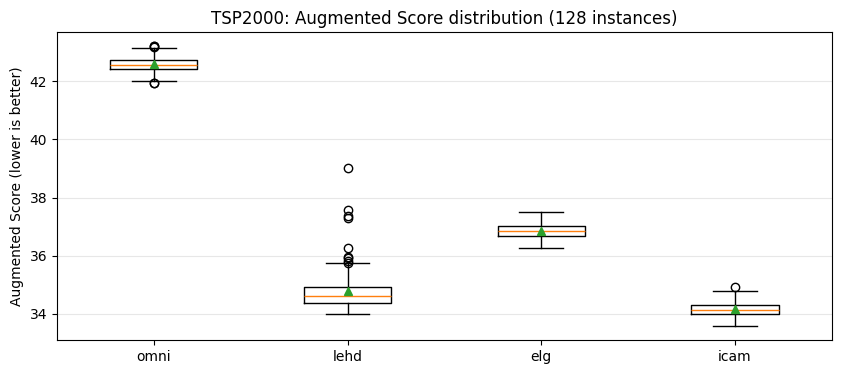

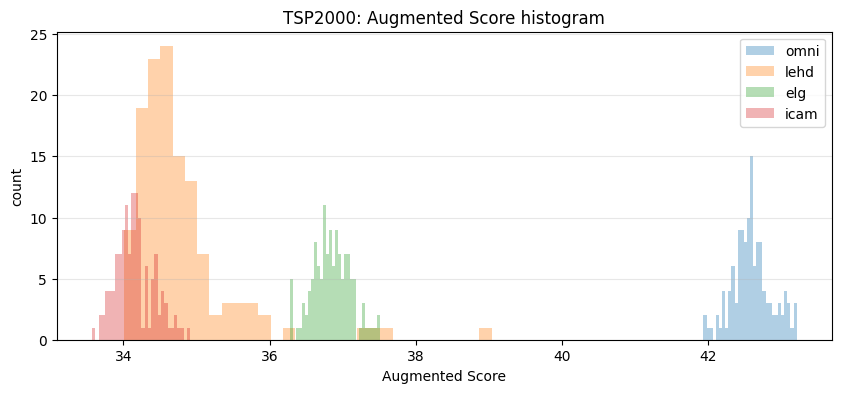

In [10]:
aug_arrays = []
for m in METHODS:
    aug_arrays.append(np.array([aug_by_method[m][iid] for iid in common_ids], dtype=float))

plt.figure(figsize=(10, 4))
plt.boxplot(aug_arrays, tick_labels=METHODS, showmeans=True)
plt.title('TSP2000: Augmented Score distribution (128 instances)')
plt.ylabel('Augmented Score (lower is better)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
bins = 30
for arr, m in zip(aug_arrays, METHODS):
    plt.hist(arr, bins=bins, alpha=0.35, label=m)
plt.title('TSP2000: Augmented Score histogram')
plt.xlabel('Augmented Score')
plt.ylabel('count')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()


## 7) 备注（非常重要，但这里不展开）\n
\n
这 4 个方法在平台默认配置下的预算并不一致（例如 `aug_factor`、`pomo_size`、是否有 iteration 等），因此“谁 win 更多”在解释时要非常小心：\n
- 这份 notebook 做的是**现有日志的客观胜负统计**；\n
- 如果你要做更严格的“公平对比”，建议先把预算口径固定（详见 `plan.md` 的第 16 节）。\n